In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_rmsf)=
# Get RMSF

*Calculating root-mean-square fluctuations per atom over a trajectory.*

The function {func}`molsysmt.structure.get_rmsf` computes the root-mean-square fluctuation (RMSF) of each atom around its time-averaged spatial position across a trajectory or structural ensemble.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_rmsf`.
:::


## Basic usage

Let's show how to calculate atomic fluctuations over a pentalanine simulation (first superposing all frames onto the reference frame to isolate pure internal flexibility from rigid-body tumbling):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])
molsys_fitted = msm.structure.least_rmsd_fit(molsys, selection='all', selection_fit='backbone', reference_structure_index=0)


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We calculate the RMSF across all atoms using {func}`molsysmt.structure.get_rmsf`:


In [4]:
rmsf_all = msm.structure.get_rmsf(molsys_fitted, selection='all')


In [5]:
print('RMSF array shape:', rmsf_all.shape)
print(f'Average RMSF over all atoms: {rmsf_all.mean():.4f}')


RMSF array shape: (62,)
Average RMSF over all atoms: 0.2551 nanometer


## Plotting per-atom fluctuation profile

We plot the RMSF profile along all atom indices to identify regions of elevated atomic flexibility:


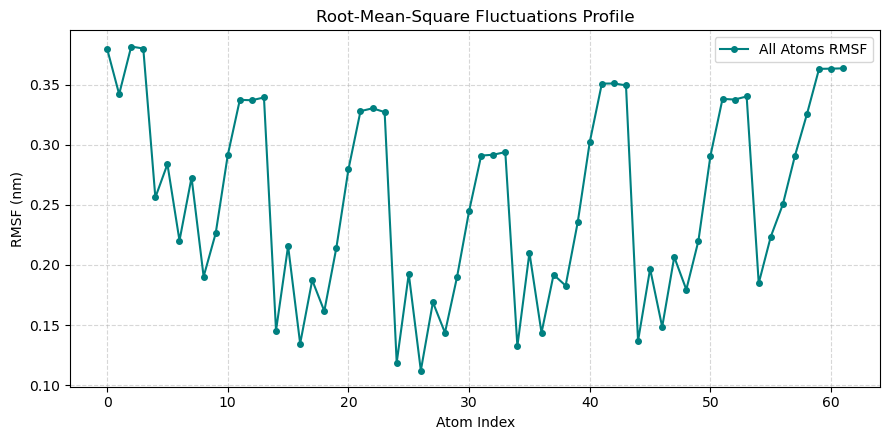

In [6]:
rmsf_val = puw.get_value(rmsf_all, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(range(len(rmsf_val)), rmsf_val, marker='o', color='teal', lw=1.5, markersize=4, label='All Atoms RMSF')
plt.xlabel('Atom Index')
plt.ylabel('RMSF (nm)')
plt.title('Root-Mean-Square Fluctuations Profile')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Per-residue fluctuation analysis

We can compute the average fluctuation for each residue group to assess backbone and sidechain mobility by residue:


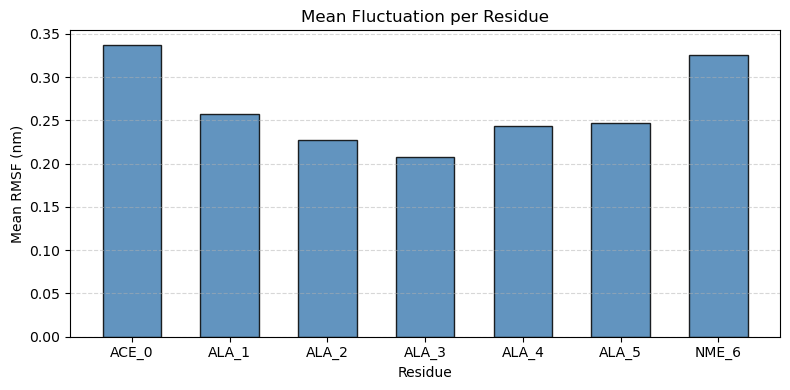

In [7]:
groups = msm.get(molsys, element='group', atom_index=True)
group_names = msm.get(molsys, element='group', name=True)
res_rmsf = [np.mean(rmsf_val[atom_idx]) for atom_idx in groups]

plt.figure(figsize=(8, 4))
plt.bar(range(len(res_rmsf)), res_rmsf, color='steelblue', edgecolor='black', alpha=0.85, width=0.6)
plt.xticks(range(len(res_rmsf)), [f'{name}_{i}' for i, name in enumerate(group_names)])
plt.xlabel('Residue')
plt.ylabel('Mean RMSF (nm)')
plt.title('Mean Fluctuation per Residue')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Least RMSD fit <Tutorial_Least_rmsd_fit>`: Superpose trajectory frames to remove rigid-body tumbling with {func}`molsysmt.structure.least_rmsd_fit`.
- {ref}`Get RMSD <Tutorial_Get_rmsd>`: Compute root-mean-square deviations with {func}`molsysmt.structure.get_rmsd`.
- {ref}`Get radius of gyration <Tutorial_Get_radius_of_gyration>`: Measure conformational compactness with {func}`molsysmt.structure.get_radius_of_gyration`.
- {ref}`Principal Component Analysis <Tutorial_Principal_component_analysis>`: Identify principal modes of collective motion with {func}`molsysmt.structure.principal_component_analysis`.
:::
